In [ ]:
!pip install Sastrawi
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

from wordcloud import WordCloud

# 🔥 FIX SEMUA ERROR NLTK
nltk.download('punkt')
nltk.download('punkt_tab')   # penting di versi baru
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.5 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv('indodax2.csv')

df = df[['content', 'score']]
df.dropna(inplace=True)

print(df.head())

                                             content  score
0   ganti app sebelah aja mending, FEE MUAHAL.BANGET    1.0
1                                     Fee mahal boss    1.0
2                                       mengecewakan    1.0
3  Biaya transaksi mahal,fee penarikan mahal,tran...    1.0
4  stressss, dah tau lg mines masih ae di palak f...    1.0


In [ ]:
def convert_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['score'].apply(convert_sentiment)
df['text'] = df['content']

print(df['sentiment'].value_counts())

sentiment
positive    1693
negative     746
neutral       60
Name: count, dtype: int64


In [ ]:
stop_words = set(stopwords.words('indonesian'))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)  # 🔥 pakai NLTK

    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]

    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

print(df[['text','clean_text']].head())

                                                text  \
0   ganti app sebelah aja mending, FEE MUAHAL.BANGET   
1                                     Fee mahal boss   
2                                       mengecewakan   
3  Biaya transaksi mahal,fee penarikan mahal,tran...   
4  stressss, dah tau lg mines masih ae di palak f...   

                                          clean_text  
0       ganti app belah aja mending fee muahalbanget  
1                                     fee mahal boss  
2                                             kecewa  
3  biaya transaksi mahalfee tari mahaltransaksi l...  
4  stressss dah tau lg mes ae palak fee ga ngotak...  


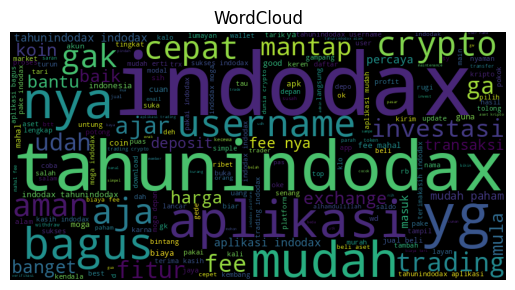

In [ ]:
text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud")
plt.show()

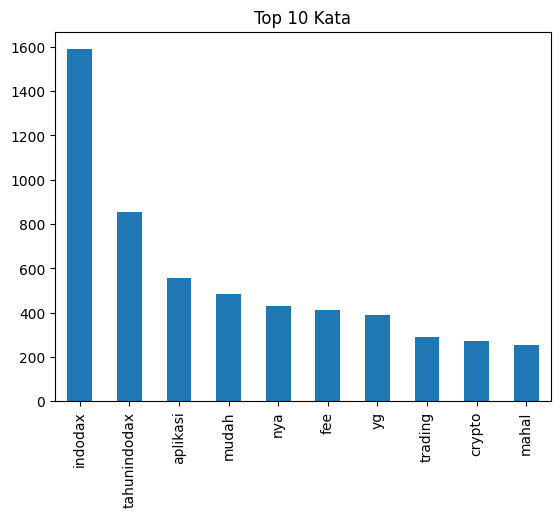

In [ ]:
freq = pd.Series(text.split()).value_counts()[:10]

freq.plot(kind='bar')
plt.title("Top 10 Kata")
plt.show()

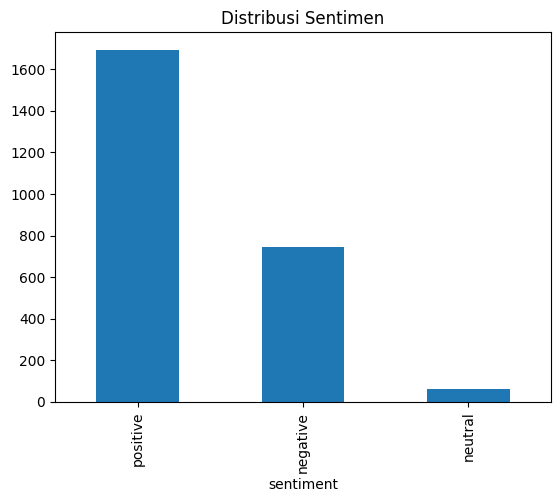

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen")
plt.show()

In [ ]:
bow = CountVectorizer()
X_bow = bow.fit_transform(df['clean_text'])
y = df['sentiment']

X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)

model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)

pred_bow = model_bow.predict(X_test_bow)

acc_bow = accuracy_score(y_test, pred_bow)

print("Accuracy BoW:", acc_bow)

Accuracy BoW: 0.914


In [ ]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['clean_text'])

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = model_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, pred_tfidf)

print("Accuracy TF-IDF:", acc_tfidf)

Accuracy TF-IDF: 0.876


In [ ]:
print("=== PERBANDINGAN ===")
print("BoW:", acc_bow)
print("TF-IDF:", acc_tfidf)

if acc_tfidf > acc_bow:
    print("TF-IDF lebih baik")
else:
    print("Bag of Words lebih baik")

=== PERBANDINGAN ===
BoW: 0.914
TF-IDF: 0.876
Bag of Words lebih baik


In [ ]:
sample = "mantap cuma ya agak mahal"

sample_clean = preprocess(sample)

sample_vec = tfidf.transform([sample_clean])
pred = model_tfidf.predict(sample_vec)

print("Kalimat:", sample)
print("Prediksi:", pred[0])

Kalimat: mantap cuma ya agak mahal
Prediksi: positive
